# 02 · Summer heat: street trees and light paving in Barcelona

**Question:** how much do street trees and lighter paving cool a dense block in the hottest week of the year?

We run two thermal comfort analyses on the Eixample / Sant Antoni district of Barcelona:

- **UTCI** (thermal comfort index): how hot the street *feels*, in °C.
- **Heat-stress statistics** (TCS): the share of summer hours with heat stress, in %.

We compare today with a scenario: a new tree every 16 m on the street surface,
and asphalt replaced by light concrete paving.

**Data.** This notebook has no own model, so it reads **public data** for the area
(buildings from Overture or an Infrared city overlay, public trees and ground).
With your own model, pass your layers instead (see `01_design_variants`).
The weather is a typical-year **EPW file** that we read on this machine.

In [1]:
import io
import logging
import os
import urllib.request
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import shape

from infrared_sdk import InfraredClient, parse_epw
from infrared_sdk.analyses.types import (
    AnalysesName, TcsModelBaseRequest, TcsModelRequest, TcsSubtype,
    UtciModelBaseRequest, UtciModelRequest)
from infrared_sdk.models import Location, TimePeriod

import ir_plot as irp

os.environ["INFRARED_QUIET"] = "1"  # no progress lines
logging.getLogger("infrared_sdk").setLevel(logging.ERROR)  # no start-up notes
client = InfraredClient()  # reads INFRARED_API_KEY

## 1. Area and public layers

A square of 600 m around the Sant Antoni market. `irp.cached_object` keeps the layers on disk.

In [2]:
lon, lat = 2.1620, 41.3790
polygon = irp.site(lon, lat, width_m=600)
buildings = irp.cached_object("barcelona-buildings", lambda: client.buildings.get_area(polygon))
trees = irp.cached_object("barcelona-trees", lambda: client.vegetation.get_area(polygon))
ground = irp.cached_object("barcelona-ground", lambda: client.ground_materials.get_area(polygon))
print(f"{len(buildings.buildings)} buildings, {trees.total_trees} trees, ground layers: "
      + ", ".join(f"{k} {len(v['features'])}" for k, v in ground.layers.items()))

3060 buildings, 1285 trees, ground layers: water 2, concrete 48, vegetation 125, soil 3, asphalt 637


## 2. Weather: the hottest week of the EPW file

`parse_epw` reads and checks the file on your machine. Nothing is uploaded as a file.
We look for the 7 days with the highest mean daily maximum in July and August.

In [3]:
EPW_URL = ("https://climate.onebuilding.org/WMO_Region_6_Europe/ESP_Spain/CT_Catalonia/"
           "ESP_CT_Barcelona.081800_TMYx.2009-2023.zip")

def download_epw() -> bytes:
    archive = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(EPW_URL).read()))
    return archive.read(next(n for n in archive.namelist() if n.endswith(".epw")))

weather = parse_epw(irp.cached_object("barcelona-epw", download_epw))

summer = weather.filter_hours(TimePeriod(start_month=7, start_day=1, start_hour=0,
                                         end_month=8, end_day=31, end_hour=23))
daily_max = np.array([h.dryBulbTemperature for h in summer]).reshape(-1, 24).max(axis=1)
start = int(np.argmax(np.convolve(daily_max, np.ones(7) / 7, mode="valid")))
day = pd.Timestamp("2001-07-01") + pd.Timedelta(days=start)  # any non-leap year
end = day + pd.Timedelta(days=6)
print(f"hottest week: {day:%d %b} to {end:%d %b}, mean daily max {daily_max[start:start + 7].mean():.1f} °C")

hottest week: 30 Jul to 05 Aug, mean daily max 29.8 °C

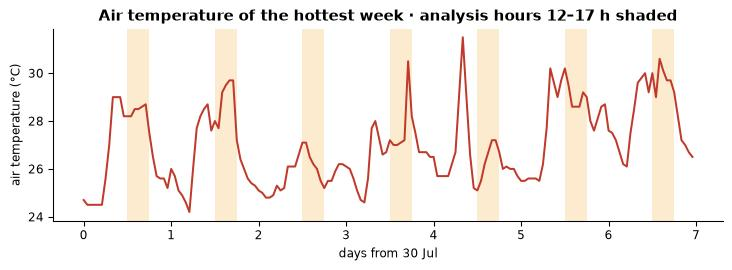

In [4]:
period = TimePeriod(start_month=day.month, start_day=day.day, start_hour=12,
                    end_month=end.month, end_day=end.day, end_hour=17)
hours = weather.filter_hours(TimePeriod(start_month=day.month, start_day=day.day, start_hour=0,
                                        end_month=end.month, end_day=end.day, end_hour=23))
air = np.array([h.dryBulbTemperature for h in hours])
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(np.arange(len(air)) / 24, air, color="#c0392b", lw=1.5)
for d in range(7):
    ax.axvspan(d + 12 / 24, d + 18 / 24, color="#f5b041", alpha=0.25, lw=0)
ax.set(xlabel=f"days from {day:%d %b}", ylabel="air temperature (°C)",
       title="Air temperature of the hottest week · analysis hours 12–17 h shaded")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

UTCI uses this hot week, 12–17 h. The heat-stress statistics use the whole summer
(June to September, 10–18 h), so they show how often a place is too hot.

A `TimePeriod` is a date span with a daily hour range. It may also wrap the year end:
1 Dec to 28 Feb is one winter window.

## 3. The scenario: street trees and light paving

All in your own hands: we change the input layers, not the model.
New trees: a plane tree (`Platanus`, 10 m high, 8 m crown) every 16 m on the street
surface, at least 8 m from an existing tree. Light paving: the `asphalt` layer becomes `concrete`.

In [5]:
utm = gpd.GeoSeries([shape(polygon)], crs=4326).estimate_utm_crs()  # a metric frame
area = gpd.GeoSeries([shape(polygon)], crs=4326).to_crs(utm).iloc[0]
roads = gpd.GeoDataFrame.from_features(ground.layers["asphalt"]["features"], crs=4326).to_crs(utm)
street = roads.union_all().intersection(area).buffer(-2)  # keep 2 m off the kerb

x0, y0, x1, y1 = street.bounds
xs, ys = np.meshgrid(np.arange(x0, x1, 16), np.arange(y0, y1, 16))
spots = gpd.GeoSeries(gpd.points_from_xy(xs.ravel(), ys.ravel()), crs=utm)
existing = gpd.GeoDataFrame.from_features(list(trees.features.values()), crs=4326).to_crs(utm)
spots = spots[spots.within(street) & (spots.distance(existing.union_all()) > 8)].to_crs(4326)

new_trees = {f"new-{i}": {"type": "Feature",
                          "geometry": {"type": "Point", "coordinates": [p.x, p.y]},
                          "properties": {"genus": "Platanus", "height": 10, "crownDiameter": 8}}
             for i, p in enumerate(spots)}
paving = {k: v for k, v in ground.layers.items() if k not in ("asphalt", "concrete")}
paving["concrete"] = {"type": "FeatureCollection", "features":
                      ground.layers["asphalt"]["features"] + ground.layers["concrete"]["features"]}

scenario = {
    "today": dict(vegetation=trees.features, ground_materials=ground.layers),
    "trees + light paving": dict(vegetation={**trees.features, **new_trees},
                                 ground_materials=paving),
}
print(f"{len(new_trees)} new street trees")

1288 new street trees


## 4. Two analyses in one call

One call takes a list of analyses. Both are thermal comfort analyses on the same tile grid,
so they share one geometry upload for each tile.

In [6]:
location = Location(latitude=lat, longitude=lon)
utci = UtciModelRequest.from_weatherfile_payload(
    payload=UtciModelBaseRequest(analysis_type=AnalysesName.thermal_comfort_index),
    location=location, time_period=period, weather_data=weather)
summer_days = TimePeriod(start_month=6, start_day=1, start_hour=10,
                         end_month=9, end_day=30, end_hour=18)
heat = TcsModelRequest.from_weatherfile_payload(
    payload=TcsModelBaseRequest(analysis_type=AnalysesName.thermal_comfort_statistics,
                                subtype=TcsSubtype.heat_stress),
    location=location, time_period=summer_days, weather_data=weather)

jobs = sum(client.preview_area(polygon, payload=p).would_bill_jobs for p in (utci, heat))
print(f"{jobs} jobs for each scenario, {2 * jobs} jobs in all")

8 jobs for each scenario, 16 jobs in all


In [7]:
results = {name: irp.cached(f"barcelona-heat-{i}", lambda: client.run_area_and_wait(
               [utci, heat], polygon, buildings=buildings, **layers))
           for i, (name, layers) in enumerate(scenario.items())}
(utci_now, heat_now), (utci_new, heat_new) = results.values()

## 5. UTCI today

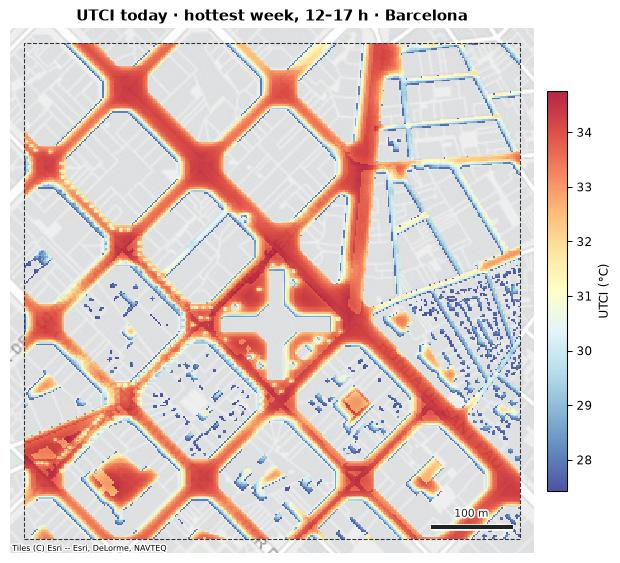

In [8]:
irp.map_grid(utci_now, polygon=polygon, title="UTCI today · hottest week, 12–17 h · Barcelona",
             label="UTCI (°C)")
plt.show()

**What you see:** the wide streets and crossings of the Eixample are the hottest
places (red): full sun all afternoon. The narrow streets in the east and the shaded
strips along the facades are cooler (blue). Grey cells are buildings.

The default UTCI model keeps the heat of walls (about 3 h) and of the ground (about 43 min)
from the hours before. The air temperature comes from the weather file.

## 6. What the scenario changes

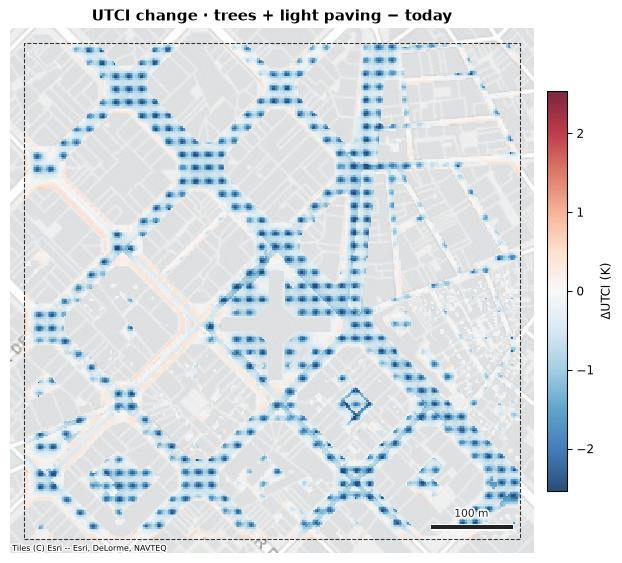

In [9]:
delta = utci_new - utci_now
limit = irp.symmetric_limit(delta)
irp.map_grid(delta, polygon=polygon, cmap="RdBu_r", vmin=-limit, vmax=limit,
             label="ΔUTCI (K)", title="UTCI change · trees + light paving − today")
plt.show()

**What you see:** each new tree makes a cool spot under its crown (blue). Between the
trees the light paving makes the street a little warmer (light red): a light surface
sends more sun back to the people on it. The cooling comes from the shade of the
trees, not from the paving.

## 7. Hours of heat stress

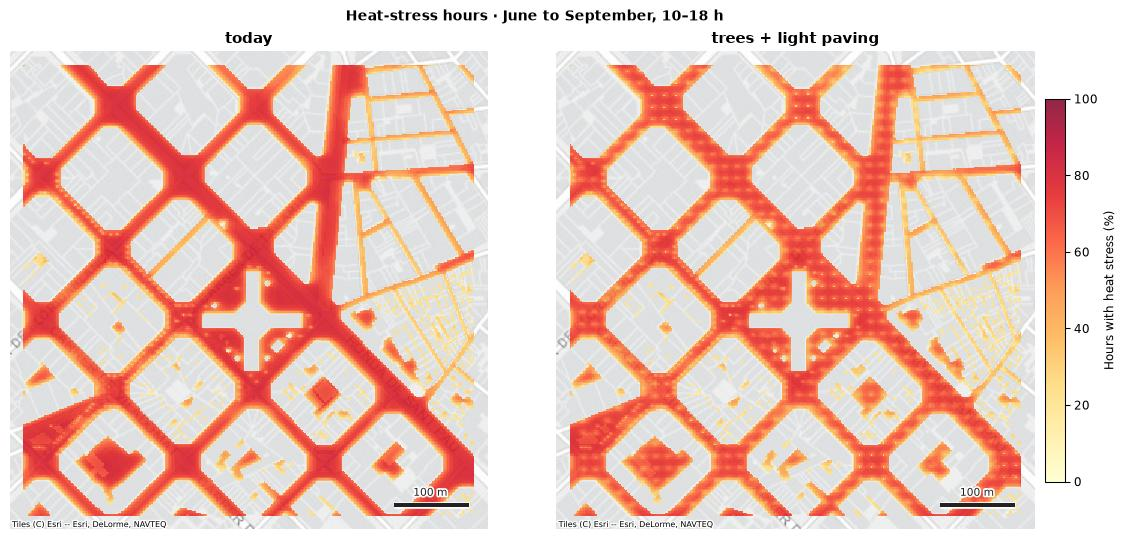

In [10]:
irp.map_grids([heat_now, heat_new], ["today", "trees + light paving"], vmin=0, vmax=100,
              label="Hours with heat stress (%)", panel=5.5,
              suptitle="Heat-stress hours · June to September, 10–18 h")
plt.show()

**What you see:** today the open streets have heat stress in most of the summer
daytime hours. With the new trees the share drops under each crown (the dotted
pattern). Courtyards and narrow streets have fewer hot hours in both maps.

## 8. Summary

In [11]:
open_ground = np.isfinite(utci_now.values) & np.isfinite(utci_new.values)
pd.DataFrame({
    "mean UTCI (°C)": [utci_now.values[open_ground].mean(), utci_new.values[open_ground].mean()],
    "summer heat-stress hours (%)": [np.nanmean(heat_now.values[open_ground]),
                              np.nanmean(heat_new.values[open_ground])],
}, index=list(scenario)).astype(float).round(2)

,mean UTCI (°C),summer heat-stress hours (%)
today,32.11,58.98
trees + light paving,31.55,53.99


## Next

- `03_wind_comfort`: wind speed and pedestrian wind comfort.
- Guide, weather and time: <https://infrared.city/docs/sdk/1.0/#weather-and-time-period>
- Guide, materials: <https://infrared.city/docs/sdk/1.0/#material-and-building-properties>